# Crime early warning on H3 cells: offline walkthrough

A standalone look at one question: **is an area's crime about to run above its own normal?** It uses only
the raw Chicago crime and 311 exports and a laptop. The notebook follows the pipeline in order and
reads the outputs the step scripts already wrote, so it runs top to bottom in about half a minute.

| Step | Script | Output |
|---|---|---|
| 0 | `preprocess.py` | cleaned crime + 311, each row tagged with H3 cells |
| 1 | `panel.py` | 770 r8 cells × weekly counts |
| 2 | `backtest.py` | walk-forward test setup + baselines |
| 3 | `features.py` | 96 features per (cell, cutoff) + leakage checks |
| 4 | `models.py` | crime-only Poisson GLM and gradient-boosted trees |
| 5 | `ablation.py` | does 311 help? (with a shuffled-311 placebo) |
| 6 | `early_warning.py` | calibrated up/down calls at r7 + a live forecast |

### Short version
- **"Where" is easy, "when" is hard.**
  - A cell's past-year average predicts its next month almost perfectly across the city (r ≈ 0.95).
  - Whether it will run *above its own normal* barely carries over from one period to the next (r ≈ 0.18).
  - About two-thirds of that month-to-month variation in a cell is pure chance.
- **The crime-only GLM beats a seasonal baseline by 3.6%** of Poisson deviance per cell (4.9% per r7
  area), and it does so in every test year from 2022 to 2026. That's small but reliable.
- **311 adds nothing measurable.**
  - Adding 66 311 features changes the GLM by −0.9% and the trees by 0.0%.
  - A shuffled-311 placebo does just as well.
  - No single request type helps either.
  - This is a real null result at this grain and horizon.
- **The early-warning calls are honest but sparse.**
  - About 8% of area-weeks get an up or down call, and those calls are right about 67–68% of the
    time, against a 53% base rate.
  - Everything else is "unclear."

*Numbers in the prose are from the 2026-09-25 run. The code cells recompute everything from the saved outputs.*

In [1]:
# The notebook lives in offline_ml/ and borrows helpers from the step scripts beside it.
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from h3.api import basic_int as h3
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, str(Path.cwd()))
from config import CLEAN, MODEL, PANEL, TEST_START

pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_float_precision(3)
pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(160)

# Chart palette: the validated reference palette, light surface.
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"          # categorical slots 1-3
UP, DOWN, NEUTRAL = "#e34948", "#2a78d6", "#f0efec"            # diverging poles + gray midpoint
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
})


def hex_map(ax, cells, colors, edge=SURFACE, lw=0.4):
    """Draw H3 cells (int ids) as polygons, lng/lat with Chicago's aspect ratio."""
    polys = [[(lng, lat) for lat, lng in h3.cell_to_boundary(int(c))] for c in cells]
    ax.add_collection(PolyCollection(polys, facecolors=colors, edgecolors=edge, linewidths=lw))
    ax.autoscale_view()
    ax.set_aspect(1 / np.cos(np.radians(41.84)))
    ax.axis("off")

## 1. The data after cleaning

`preprocess.py` turns the raw exports into two clean tables (the rules and the numbers behind them are
in `README.md`). The two decisions that matter most here:
- **311 keeps only place-based requests.** It drops "information only" calls, which sit on the 311 call
  center's address, and aircraft-noise complaints, which all sit on one O'Hare address. Together those
  were 53% of raw 311 rows.
- **Crime with missing coordinates is filled from its block's median point.** On held-out rows, that fill
  landed a median of 14 m from the real location.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


crimes: 8,642,798 raw -> 8,638,566 clean
311:    14,655,891 raw -> 6,836,544 clean (place-based only)


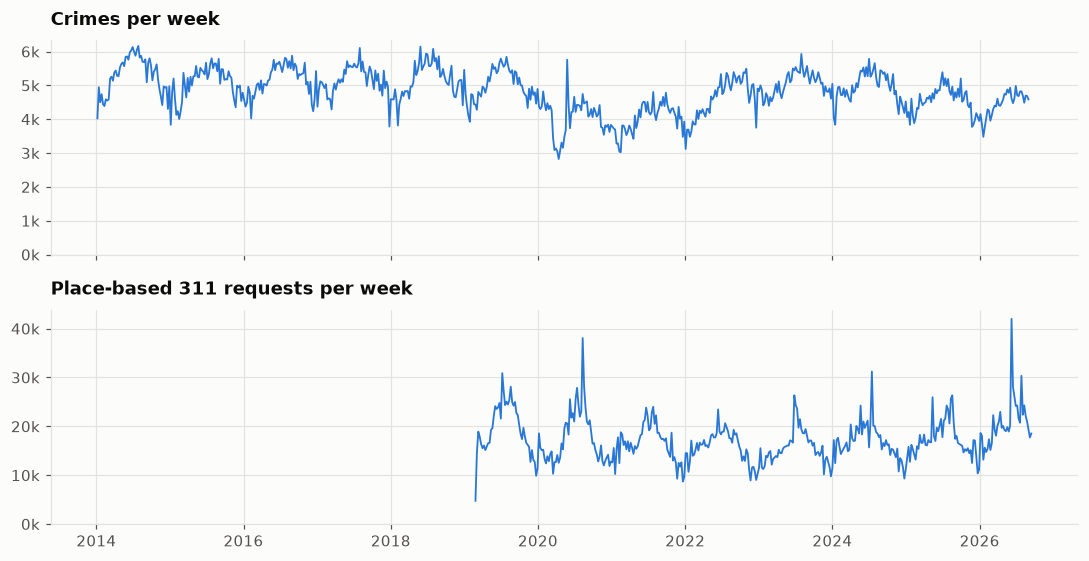

In [2]:
log = json.loads((CLEAN / "cleaning_log.json").read_text())
crimes = pl.read_parquet(CLEAN / "crimes.parquet", columns=["occurred_at", "h3_r8"])
sr = pl.read_parquet(CLEAN / "sr311.parquet", columns=["created_at", "sr_type"])
print(f"crimes: {log['crimes']['raw rows']:,} raw -> {log['crimes']['final rows']:,} clean")
print(f"311:    {log['sr311']['raw rows']:,} raw -> {log['sr311']['final rows']:,} clean (place-based only)")

weekly = lambda df, col: df.group_by(pl.col(col).dt.truncate("1w").alias("week")).len().sort("week")
cw = weekly(crimes.filter(pl.col("occurred_at") >= pl.datetime(2014, 1, 6)), "occurred_at")
sw = weekly(sr, "created_at")
cw, sw = cw.filter(pl.col("week") < cw["week"].max()), sw.filter(pl.col("week") < sw["week"].max())  # drop partial last weeks

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
axes[0].plot(cw["week"], cw["len"], color=BLUE, lw=1.2)
axes[0].set_title("Crimes per week")
axes[1].plot(sw["week"], sw["len"], color=BLUE, lw=1.2)
axes[1].set_title("Place-based 311 requests per week")
for ax in axes:
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")
fig.tight_layout()

311's biggest spikes are storm weeks, when tree-emergency and tree-debris requests surge (the
week of 2020-08-10 is that August's derecho). One more spike is a 2019 lead-test-kit campaign. Crime's
2020 dip is COVID. That dip matters later, because every training row before 2022 falls in that era.

## 2. The spatial unit: H3 cells

Every event carries an H3 cell id at resolution 9 (~0.1 km²), plus its r8 and r7 parents.
- **The models work at r8** (~0.7 km², ~5 crimes per cell-week).
- **The calls are also judged at r7** (~5 km², seven r8 cells).
- **The modeled cells** are the 770 r8 cells averaging at least 12 crimes a year. They were chosen from
  pre-2022 data only, so the test period can't influence which cells are in. They hold 99.7% of crime
  since 2022.

H3 cells are equal-area. That makes "the top 5% of cells" the same as "5% of the city's area."

770 r8 cells, 141 r7 areas; median 216 crimes/yr per cell (range 12-3,124)


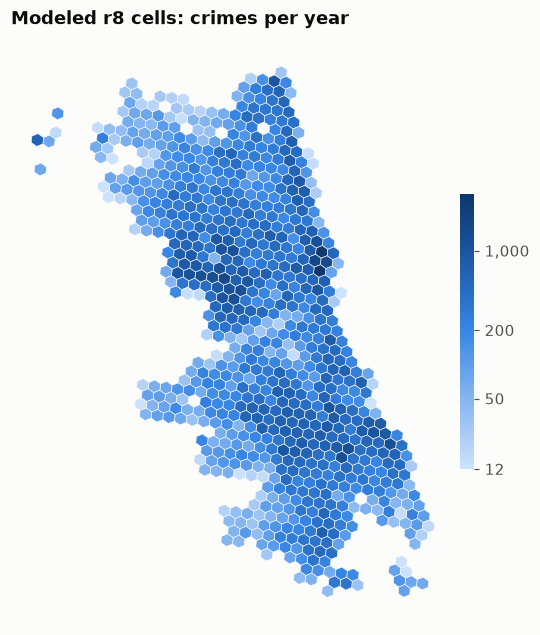

In [3]:
cells = pl.read_parquet(PANEL / "cells.parquet")
print(f"{cells.height} r8 cells, {cells['h3_r7'].n_unique()} r7 areas; "
      f"median {cells['crimes_per_year_pre'].median():.0f} crimes/yr per cell (range {cells['crimes_per_year_pre'].min():.0f}-{cells['crimes_per_year_pre'].max():,.0f})")

rate = np.log10(cells["crimes_per_year_pre"].to_numpy())
norm = (rate - rate.min()) / (rate.max() - rate.min())
fig, ax = plt.subplots(figsize=(6.2, 7.2))
hex_map(ax, cells["h3_r8"], SEQ_BLUE(norm))
ax.set_title("Modeled r8 cells: crimes per year")
sm = plt.cm.ScalarMappable(cmap=SEQ_BLUE, norm=plt.Normalize(rate.min(), rate.max()))
cb = fig.colorbar(sm, ax=ax, shrink=0.45, pad=0.01)
cb.set_ticks([np.log10(v) for v in (12, 50, 200, 1000) if rate.min() <= np.log10(v) <= rate.max()])
cb.set_ticklabels([f"{v:,}" for v in (12, 50, 200, 1000) if rate.min() <= np.log10(v) <= rate.max()])
cb.outline.set_visible(False)

## 3. How much is even predictable?

This check decides the whole design. For each grain and time window, the table below compares three things:
- **where r:** how well a unit's trailing-year average predicts its next count, across all units. This
  is the easy part.
- **when r:** how well this period's departure from normal predicts the next period's. This is the
  early-warning part.
- **noise share:** how much of the variation in those departures pure Poisson chance would produce on
  its own.

In [4]:
# How predictable is "this area is running above its own normal"? Periods starting 2022+ (the test years):
#   where r - trailing-year average vs the next count, across all units (the easy part)
#   when r  - this period's departure from normal vs the next period's (the early-warning part)
#   noise   - share of the variance in next-period departures that pure Poisson chance would
#             produce around the trailing average (simulated, so it holds at small counts too)
weekly_grid = pl.read_parquet(PANEL / "crime_weekly.parquet").filter(pl.col("week") >= pl.date(2019, 3, 4))
rng = np.random.default_rng(0)

def predictability(unit: str, weeks: int) -> dict:
    per_year = round(52 / weeks)
    g = (weekly_grid.with_columns(((pl.col("week") - pl.date(2019, 3, 4)).dt.total_days() // (7 * weeks)).alias("p"))
         .group_by(unit, "p").agg(pl.col("crime_n").sum().alias("n"), pl.col("week").min().alias("start")).sort(unit, "p")
         .with_columns(pl.col("n").shift(1).rolling_mean(per_year).over(unit).alias("trail"),
                       pl.col("n").shift(1).over(unit).alias("last"))
         .drop_nulls())
    g = g.filter((pl.col("p") < g["p"].max()) & (pl.col("start") >= pl.date(2022, 1, 1)))   # last period may be partial
    n, trail, last = (g[c].to_numpy().astype(float) for c in ("n", "trail", "last"))
    dev_next, dev_last = np.log1p(n) - np.log1p(trail), np.log1p(last) - np.log1p(trail)
    chance = np.log1p(rng.poisson(trail, size=(20, trail.size))) - np.log1p(trail)
    return {"grain": unit.replace("h3_", ""), "weeks": weeks, "mean count": n.mean(),
            "where r": np.corrcoef(trail, n)[0, 1], "when r": np.corrcoef(dev_last, dev_next)[0, 1],
            "noise share": chance.var(axis=1).mean() / dev_next.var()}

pl.DataFrame([predictability(u, w) for u in ("h3_r8", "h3_r7") for w in (1, 4, 13)])

grain,weeks,mean count,where r,when r,noise share
str,i64,f64,f64,f64,f64
"""r8""",1,6.153,0.887,0.086,0.808
"""r8""",4,24.621,0.954,0.176,0.658
"""r8""",13,80.626,0.973,0.151,0.443
"""r7""",1,33.602,0.964,0.168,0.711
"""r7""",4,134.454,0.981,0.293,0.524
"""r7""",13,440.296,0.986,0.332,0.281


- **"Where" is nearly solved by a trailing average.** Any model will score well on raw accuracy,
  so raw accuracy can't be the yardstick.
- **"When" is weak, and mostly chance at small grains.**
  - At r8 × 4 weeks, about two-thirds of a cell's departure from normal is noise.
  - Larger areas and longer windows are less noisy, but they give a slower, blunter warning.
- **So the design is to model small and report big.** Features and fits use r8, 4 weeks ahead. The calls
  are judged at r8 and, summed, at r7.

## 4. The training table, and keeping the future out of it

Each row is one **(cell, cutoff Monday)**:

```
 ← features: only events before the cutoff →    | cutoff | → target: all crimes in the next 4 weeks
 52 weeks ... 13 weeks ... 4 weeks ... 1 week    |        |
```

- **Baseline:** `expected` is the baseline forecast (section 5). The models learn departures from it.
- **Feature groups:**
  - `crime`: the cell's own history, plus its ring-1 and ring-2 neighbors
  - `311`: request volumes, per-type counts, backlog, and time to close
  - `citywide`: calendar and whole-city signals
- **Late reports:** crimes whose case was opened in a later calendar year than they occurred (1.8%)
  are kept out of features but counted in the target.

In [5]:
feats = pl.read_parquet(MODEL / "features.parquet")
from features import FEATURE_GROUPS, feature_columns
print(f"{feats.height:,} rows = {feats['h3_r8'].n_unique()} cells x {feats['cutoff'].n_unique()} weekly cutoffs "
      f"({feats['cutoff'].min()} .. {feats['cutoff'].max()})")
for g in FEATURE_GROUPS:
    cols = feature_columns(feats, (g,))
    print(f"  {g:<9} {len(cols):>3} features, e.g. {', '.join(cols[:4])}")

busiest = feats.group_by("h3_r8").agg(pl.col("c_52w").mean()).sort("c_52w", descending=True)["h3_r8"][0]
feats.filter((pl.col("h3_r8") == busiest) & (pl.col("cutoff") == pl.date(2025, 6, 2))).select(
    "h3_r8", "cutoff", "y", "expected", "c_4w", "c_52w", "c_accel_4w", "n1_c_accel_4w", "s_total_4w", "s_open")

261,800 rows = 770 cells x 340 weekly cutoffs (2020-03-02 .. 2026-08-31)
  crime      25 features, e.g. c_log_expected, c_1w, c_4w, c_13w
  311        66 features, e.g. sn1_total_4w, sn1_total_accel_4w, s_total_1w, s_total_4w
  citywide    5 features, e.g. t_season, t_week_of_year, t_city_accel_4w, t_city_accel_13w


h3_r8,cutoff,y,expected,c_4w,c_52w,c_accel_4w,n1_c_accel_4w,s_total_4w,s_open
i64,date,i32,f64,i32,i32,f64,f64,i32,i32
613164976326049791,2025-06-02,315,311.729,248,3734,-0.146,0.079,260,214


Two checks guard against features that accidentally see the future. Both run on every build, and they
run here live:
1. **Direct recount:** recompute a few features for random rows straight from the raw event tables.
2. **Truncation:** delete all data from 2024-06-03 on, rebuild everything, and require every earlier
   row's features to be identical. This one catches subtle leaks. For example, 311's `status` column
   describes *today*, so "open at the cutoff" has to be rebuilt from timestamps.

In [6]:
# Both leakage checks, run live (~10 s). They raise if any feature could see past its cutoff.
from features import check_direct, check_truncation, load_events, pick_sr_types
events_crime, events_sr = load_events()
types = pick_sr_types(pl.read_parquet(PANEL / "sr_weekly.parquet"))
weeks = pl.read_parquet(PANEL / "crime_weekly.parquet")["week"].unique().sort()
check_direct(feats, events_crime, events_sr, cells)
check_truncation(feats, events_crime, events_sr, cells, weeks, types)

  direct check: 5 features match a from-scratch recount for 8 random rows


  truncation check: all 97 features identical for 170,940 rows before 2024-06-03 when everything from 2024-06-03 on is deleted


## 5. The bar to beat

**Walk-forward test:**
- Test cutoffs run weekly from Jan 2022 to Aug 2026, in 19 quarterly folds.
- A fold only trains on cutoffs whose 4-week target ended before the fold starts.
- Random cross-validation would leak, because neighboring weeks share targets.

**The baseline** (`seasonal_trailing`) is the cell's last 52 weeks, scaled to 4 weeks, × a citywide
seasonal factor (the median of the same calendar window over the 5 prior years).

**Scores:**
- **Poisson deviance** is the standard error measure for counts. **Skill** is the % of the baseline's
  deviance a forecast removes.
- **`auc_above_normal`** asks: within a week, does the forecast rank the cells that came in above
  expected ahead of those that didn't? 0.5 is chance.
- **`noise_floor`** is the deviance a perfect forecast would still get if crime were pure Poisson
  noise.

┌───────┬──────────────────────┬──────────┬──────────────┬─────────────┬──────────────────┬──────────────┐
│ grain ┆ model                ┆ deviance ┆ skill_vs_bar ┆ noise_floor ┆ auc_above_normal ┆ top5_capture │
│ ---   ┆ ---                  ┆ ---      ┆ ---          ┆ ---         ┆ ---              ┆ ---          │
│ str   ┆ str                  ┆ f64      ┆ f64          ┆ f64         ┆ f64              ┆ f64          │
╞═══════╪══════════════════════╪══════════╪══════════════╪═════════════╪══════════════════╪══════════════╡
│ r8    ┆ seasonal_trailing    ┆ 1.811    ┆ 0.000        ┆ 1.027       ┆ 0.500            ┆ 0.189        │
│ r8    ┆ trailing             ┆ 1.882    ┆ -0.039       ┆ 1.027       ┆ 0.500            ┆ 0.189        │
│ r8    ┆ last_4_weeks         ┆ 2.718    ┆ -0.501       ┆ 1.027       ┆ 0.560            ┆ 0.186        │
│ r8    ┆ same_weeks_last_year ┆ 3.502    ┆ -0.933       ┆ 1.027       ┆ 0.500            ┆ 0.183        │
│ r7    ┆ seasonal_trailing    ┆ 2.90

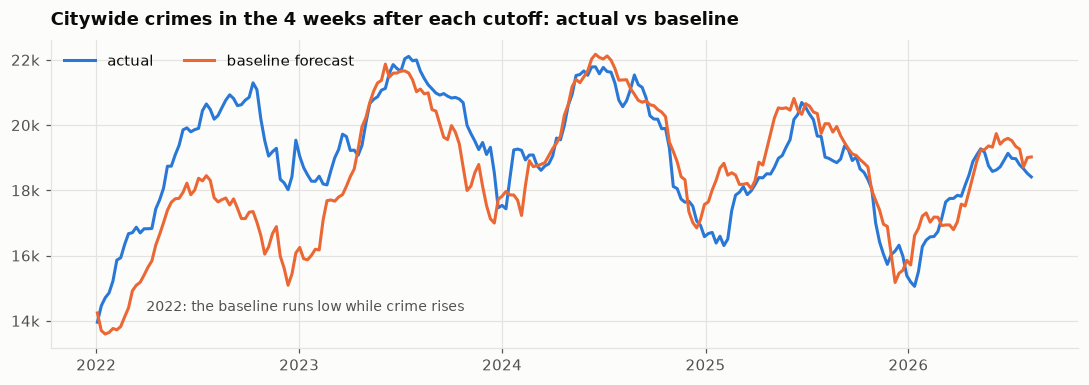

In [7]:
base = pl.read_csv(MODEL / "baseline_summary.csv")
print(base.filter(pl.col("year") == "all").select("grain", "model", "deviance", "skill_vs_bar", "noise_floor", "auc_above_normal", "top5_capture"))

bp = pl.read_parquet(MODEL / "baseline_predictions.parquet")
city = bp.group_by("cutoff").agg(pl.col("y", "seasonal_trailing").sum()).sort("cutoff")
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(city["cutoff"], city["y"], color=BLUE, label="actual")
ax.plot(city["cutoff"], city["seasonal_trailing"], color=ORANGE, label="baseline forecast")
ax.set_title("Citywide crimes in the 4 weeks after each cutoff: actual vs baseline")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")
ax.legend(loc="upper left", ncols=2)
ax.text(np.datetime64("2022-04-01"), 14_300, "2022: the baseline runs low while crime rises", color=INK_2, fontsize=9)
fig.tight_layout()

- **The baseline beats simple alternatives.** Last 4 weeks and last year's same weeks are both much worse.
- **It has two weaknesses a model could fix:**
  - it lags citywide trends (2022, above)
  - it ignores momentum, even though last 4 weeks ranks above-normal cells better than chance (AUC 0.56 at r8, 0.60 at r7).

## 6. Crime-only models

Two models learn departures from the baseline:
- a **Poisson GLM** with an L2 penalty
- **gradient-boosted trees** with a Poisson loss (scikit-learn's HistGradientBoosting, since LightGBM
  needs Homebrew's `libomp`)

**One design change came out of testing.** The first version let the models adjust the city's overall
level too.
- The trees learned citywide swings that didn't repeat. In Q1 2025 they forecast the city at 0.77× the
  baseline when it came in at 0.94×, for −84% skill that quarter.
- The *local* part of both models was steady every year.

So now **the baseline sets the citywide total and the models only redistribute it across cells**:
- **Training:** each week's expected counts are pinned to that week's actual citywide total.
- **Test:** forecasts are rescaled to the baseline's citywide total.

┌───────┬───────────────────┬──────────┬──────────────┬──────────────────┐
│ grain ┆ model             ┆ deviance ┆ skill_vs_bar ┆ auc_above_normal │
│ ---   ┆ ---               ┆ ---      ┆ ---          ┆ ---              │
│ str   ┆ str               ┆ f64      ┆ f64          ┆ f64              │
╞═══════╪═══════════════════╪══════════╪══════════════╪══════════════════╡
│ r8    ┆ seasonal_trailing ┆ 1.811    ┆ 0.000        ┆ 0.500            │
│ r8    ┆ glm_crime         ┆ 1.746    ┆ 0.036        ┆ 0.571            │
│ r8    ┆ gbm_crime         ┆ 1.761    ┆ 0.028        ┆ 0.571            │
│ r7    ┆ seasonal_trailing ┆ 2.905    ┆ 0.000        ┆ 0.500            │
│ r7    ┆ glm_crime         ┆ 2.763    ┆ 0.049        ┆ 0.580            │
│ r7    ┆ gbm_crime         ┆ 2.798    ┆ 0.037        ┆ 0.579            │
└───────┴───────────────────┴──────────┴──────────────┴──────────────────┘


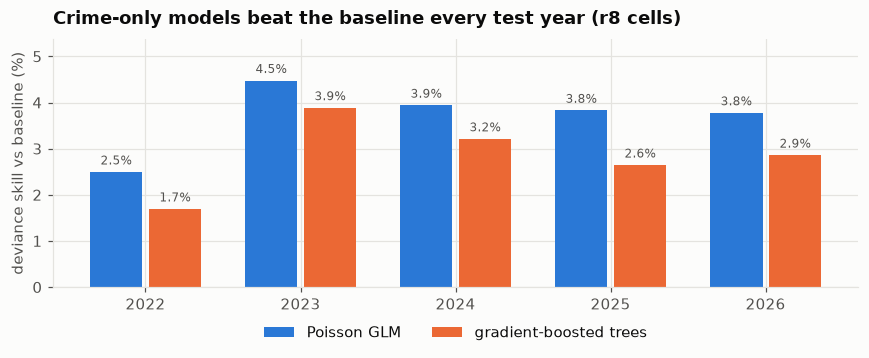

In [8]:
s4 = pl.read_csv(MODEL / "step4_summary.csv")
print(s4.filter(pl.col("year") == "all").select("grain", "model", "deviance", "skill_vs_bar", "auc_above_normal"))

yr = s4.filter((pl.col("grain") == "r8") & (pl.col("year") != "all") & (pl.col("model") != "seasonal_trailing"))
years = sorted(yr["year"].unique().to_list())
fig, ax = plt.subplots(figsize=(8, 3.4))
w = 0.38
for i, (m, color, label) in enumerate((("glm_crime", BLUE, "Poisson GLM"), ("gbm_crime", ORANGE, "gradient-boosted trees"))):
    vals = [100 * yr.filter((pl.col("model") == m) & (pl.col("year") == y))["skill_vs_bar"].item() for y in years]
    xs = np.arange(len(years)) + (i - 0.5) * w
    ax.bar(xs, vals, width=w - 0.04, color=color, label=label)
    for x, v in zip(xs, vals):
        ax.text(x, v + 0.1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8, color=INK_2)
ax.set_xticks(range(len(years)), years)
ax.set_ylabel("deviance skill vs baseline (%)")
ax.set_title("Crime-only models beat the baseline every test year (r8 cells)")
ax.set_ylim(0, max(100 * yr["skill_vs_bar"].max() * 1.2, 1))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=2)
fig.tight_layout()

The simpler GLM wins. At this signal-to-noise, the trees' interactions just add variance.

**What the GLM leans on** (red raises the forecast, blue lowers it):
- **Regression to the mean.** Cells with a high expected count come in lower. The trailing average
  overshoots in busy cells.
- **Momentum.** Recent weeks, both the cell's and its neighbors', push the forecast up.
- **Reversion.** A rise over the past year predicts a partial fall back.

The lookback windows overlap, so read the coefficients as a group, not one by one.

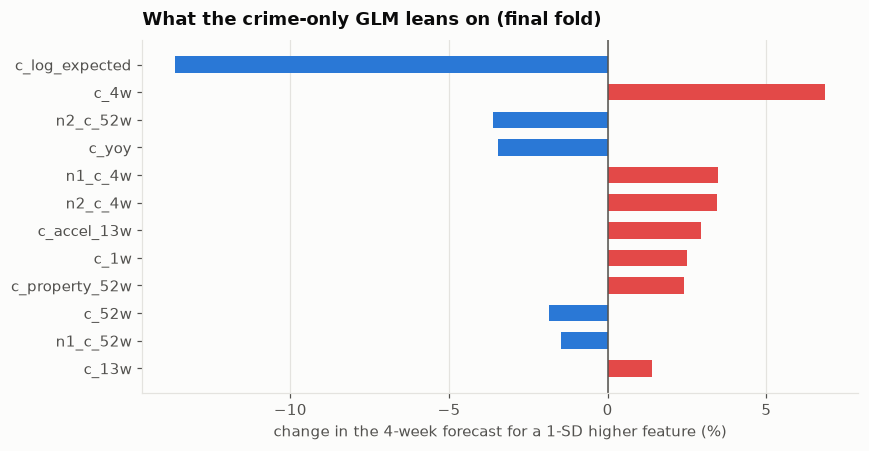

In [9]:
coef = pl.read_csv(MODEL / "step4_glm_coefficients.csv").head(12).reverse()
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [UP if v > 0 else DOWN for v in coef["pct_per_sd"]]
ax.barh(coef["feature"], coef["pct_per_sd"], color=colors, height=0.6)
ax.axvline(0, color=INK_2, lw=1)
ax.set_xlabel("change in the 4-week forecast for a 1-SD higher feature (%)")
ax.set_title("What the crime-only GLM leans on (final fold)")
ax.grid(axis="y", visible=False)
fig.tight_layout()

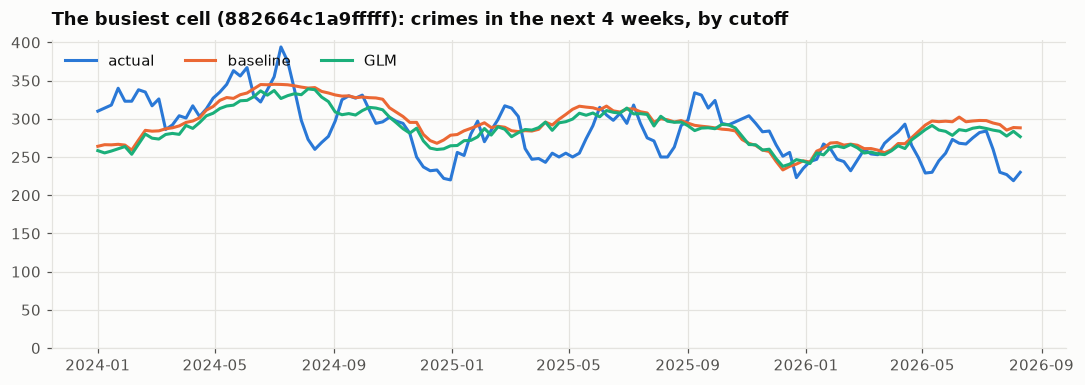

In [10]:
p4 = pl.read_parquet(MODEL / "step4_predictions.parquet")
one = p4.filter((pl.col("h3_r8") == busiest) & (pl.col("cutoff") >= pl.date(2024, 1, 1))).sort("cutoff")
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(one["cutoff"], one["y"], color=BLUE, label="actual")
ax.plot(one["cutoff"], one["seasonal_trailing"], color=ORANGE, label="baseline")
ax.plot(one["cutoff"], one["glm_crime"], color=AQUA, label="GLM")
ax.set_title(f"The busiest cell ({h3.int_to_str(busiest)}): crimes in the next 4 weeks, by cutoff")
ax.legend(loc="upper left", ncols=3)
ax.set_ylim(bottom=0)
fig.tight_layout()

In a single cell, the GLM stays close to the baseline and nudges it. Most of what's left over is
the chance variation from section 3.

## 7. The 311 experiment

This is the project's core question: **does 311 improve the forecast beyond crime's own history?**
- **Headline:** each model with and without the 311 features, on identical rows and folds.
- **Lift:** the % of the crime-only model's deviance the 311 version removes, with a CI from
  resampling whole quarters.
- **Placebo:** each week's 311 features shuffled across cells. This keeps every citywide pattern and
  breaks only the link to place. Real local signal would beat the placebo.

┌────────────────────────────────────────┬─────────┬────────┬────────┬───┬────────┬────────┬────────┬────────────┐
│ comparison                             ┆ lift_r8 ┆ lo_r8  ┆ hi_r8  ┆ … ┆ lo_r7  ┆ hi_r7  ┆ auc_r8 ┆ auc_ref_r8 │
│ ---                                    ┆ ---     ┆ ---    ┆ ---    ┆   ┆ ---    ┆ ---    ┆ ---    ┆ ---        │
│ str                                    ┆ f64     ┆ f64    ┆ f64    ┆   ┆ f64    ┆ f64    ┆ f64    ┆ f64        │
╞════════════════════════════════════════╪═════════╪════════╪════════╪═══╪════════╪════════╪════════╪════════════╡
│ glm: + 311                             ┆ -0.009  ┆ -0.013 ┆ -0.005 ┆ … ┆ -0.024 ┆ -0.003 ┆ 0.569  ┆ 0.571      │
│ glm: + shuffled 311 (placebo)          ┆ -0.005  ┆ -0.008 ┆ -0.003 ┆ … ┆ -0.008 ┆ 0.005  ┆ 0.571  ┆ 0.571      │
│ glm: real vs shuffled 311              ┆ -0.004  ┆ -0.007 ┆ -0.000 ┆ … ┆ -0.023 ┆ -0.003 ┆ 0.569  ┆ 0.571      │
│ gbm: + 311                             ┆ 0.000   ┆ -0.001 ┆ 0.002  ┆ … ┆ -0.00

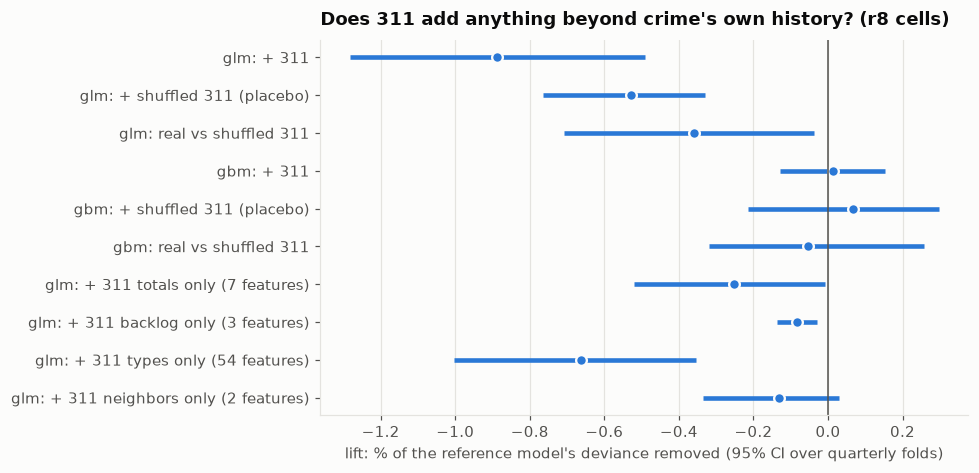

In [11]:
lift = pl.read_csv(MODEL / "step5_lift.csv")
print(lift.select("comparison", "lift_r8", "lo_r8", "hi_r8", "lift_r7", "lo_r7", "hi_r7", "auc_r8", "auc_ref_r8"))

def forest(ax, labels, est, lo, hi, color=BLUE, lo2=None, hi2=None):
    y = np.arange(len(labels))[::-1]
    if lo2 is not None:
        ax.hlines(y, lo2, hi2, color=MUTED, lw=1)
    ax.hlines(y, lo, hi, color=color, lw=3)
    ax.plot(est, y, "o", color=color, ms=7, mec=SURFACE, mew=1.5)
    ax.axvline(0, color=INK_2, lw=1)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)

fig, ax = plt.subplots(figsize=(9, 4.4))
forest(ax, lift["comparison"].to_list(), 100 * lift["lift_r8"], 100 * lift["lo_r8"], 100 * lift["hi_r8"])
ax.set_xlabel("lift: % of the reference model's deviance removed (95% CI over quarterly folds)")
ax.set_title("Does 311 add anything beyond crime's own history? (r8 cells)")
fig.tight_layout()

- **GLM:** 311 makes it slightly worse, and it does worse with real 311 than with shuffled 311. The
  66 noisy features let it fit relationships that drift over time.
- **Trees:** they learn to ignore 311, so real and shuffled 311 both land at about 0.
- **Ranking:** AUCs don't move beyond what the placebo also shows.
- **Power:** the intervals are ±0.4% wide. So a 311 effect even a seventh the size of crime history's
  own +3.6% would have shown up here.

Each request type added on its own, to see if any single one is a leading indicator:

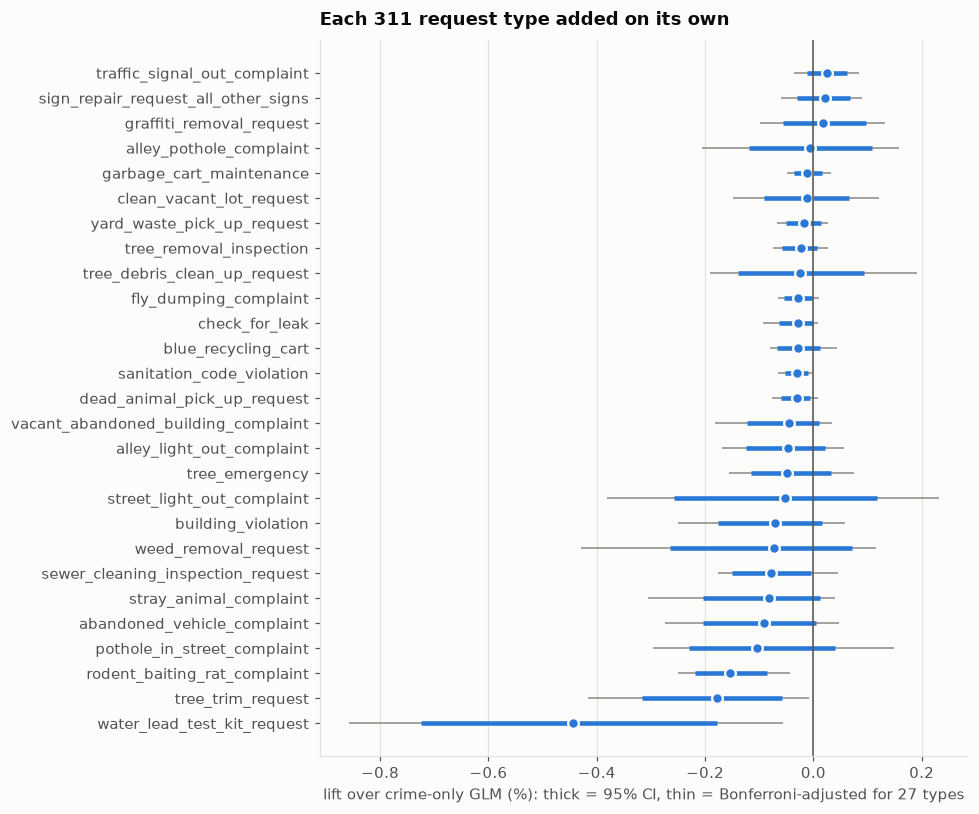

In [12]:
tl = pl.read_csv(MODEL / "step5_type_lift.csv")
fig, ax = plt.subplots(figsize=(9, 7.5))
forest(ax, tl["sr_type"].to_list(), 100 * tl["lift"], 100 * tl["lo"], 100 * tl["hi"],
       lo2=100 * tl["bonferroni_lo"], hi2=100 * tl["bonferroni_hi"])
ax.set_xlabel("lift over crime-only GLM (%): thick = 95% CI, thin = Bonferroni-adjusted for 27 types")
ax.set_title("Each 311 request type added on its own")
fig.tight_layout()

No type clears zero, even before adjusting for testing 27 of them.

**Conclusion:** at r8 × 4 weeks, recent crime already carries whatever 311 knows about next month.
That doesn't rule out 311 mattering elsewhere:
- **finer places and shorter windows**, like a streetlight outage on one block (an event-study design
  suits that better)
- **specific crime types**
- **longer horizons**

## 8. Early-warning calls

A forecast becomes **P(next 4 weeks > expected)** through a negative binomial centered on it. Its
dispersion comes only from earlier folds' out-of-sample misses, so fold 0 has no probabilities.

**Calls:** **up** if P ≥ 0.65, **down** if P ≤ 0.35, otherwise **unclear**.

**Three ways to get area-level (r7) forecasts:**
- sum the r8 model's forecasts
- fit the GLM on r7 areas directly
- a one-feature momentum model at r7

The live calls use whichever has the best Brier score, which rewards ranking and calibration together.

In [13]:
cmp7 = pl.read_csv(MODEL / "step6_r7_comparison.csv")
calls = pl.read_csv(MODEL / "step6_calls.csv")
print(cmp7)
print(calls.select("forecast", "brier", "brier_climatology", "brier_skill", "share_called", "up_hit_rate", "down_hit_rate", "n_up", "n_down"))

CHOSEN_R7 = calls.filter(pl.col("grain") == "r7").sort("brier")["forecast"][0]
print("r7 calls use:", CHOSEN_R7)

┌─────────────┬───────┬──────────┬──────────┬───────┬────────┬────────┐
│ forecast    ┆ skill ┆ skill_lo ┆ skill_hi ┆ auc   ┆ auc_lo ┆ auc_hi │
│ ---         ┆ ---   ┆ ---      ┆ ---      ┆ ---   ┆ ---    ┆ ---    │
│ str         ┆ f64   ┆ f64      ┆ f64      ┆ f64   ┆ f64    ┆ f64    │
╞═════════════╪═══════╪══════════╪══════════╪═══════╪════════╪════════╡
│ summed_r8   ┆ 0.049 ┆ 0.033    ┆ 0.066    ┆ 0.580 ┆ 0.565  ┆ 0.596  │
│ native_r7   ┆ 0.057 ┆ 0.044    ┆ 0.068    ┆ 0.574 ┆ 0.559  ┆ 0.588  │
│ momentum_r7 ┆ 0.053 ┆ 0.042    ┆ 0.065    ┆ 0.602 ┆ 0.590  ┆ 0.615  │
└─────────────┴───────┴──────────┴──────────┴───────┴────────┴────────┘
┌────────────────┬───────┬───────────────────┬─────────────┬───┬─────────────┬───────────────┬──────┬────────┐
│ forecast       ┆ brier ┆ brier_climatology ┆ brier_skill ┆ … ┆ up_hit_rate ┆ down_hit_rate ┆ n_up ┆ n_down │
│ ---            ┆ ---   ┆ ---               ┆ ---         ┆   ┆ ---         ┆ ---           ┆ ---  ┆ ---    │
│ str            ┆ 

The three r7 options are close.
- **Momentum alone ranks best** (AUC 0.60), but its probabilities score slightly worse (Brier 0.245 vs
  0.243), and its calls lean heavily toward "down."
- **The summed r8 model has the best Brier score,** so it drives the live calls.
- **Every option's Brier skill over climatology is only 3–4%.** The forecasts rarely stray far from a
  coin flip, and that's the honest shape of this problem.

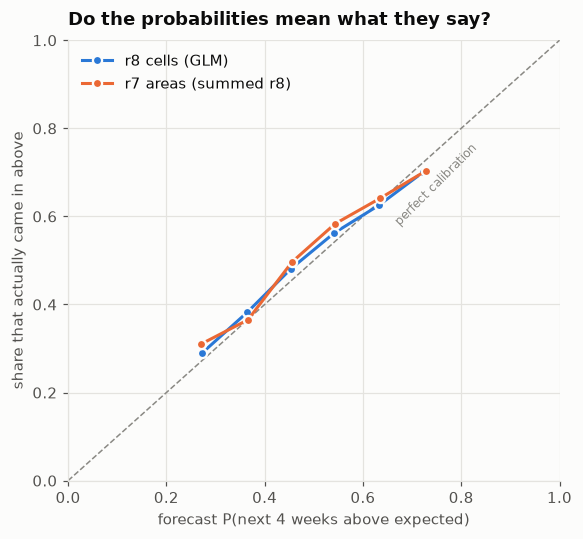

In [14]:
# Bins with fewer than 100 test rows are left off: at the extremes they hold a handful of rows.
rel = pl.read_csv(MODEL / "step6_reliability.csv").filter(pl.col("n") >= 100)
names = {"r8 glm": "r8 cells (GLM)", CHOSEN_R7: f"r7 areas ({CHOSEN_R7.split(' ', 1)[1].replace('_', ' ')})"}
fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.text(0.66, 0.58, "perfect calibration", color=MUTED, fontsize=8, rotation=45)
for f, color in zip(names, (BLUE, ORANGE)):
    d = rel.filter(pl.col("forecast") == f)
    ax.plot(d["predicted"], d["observed"], "-o", color=color, ms=6, mec=SURFACE, mew=1.5, label=names[f])
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("forecast P(next 4 weeks above expected)")
ax.set_ylabel("share that actually came in above")
ax.set_title("Do the probabilities mean what they say?")
ax.legend(loc="upper left")
fig.tight_layout()

The probabilities track outcomes well across the range where nearly all forecasts fall (0.3–0.7).
Observed rates run 1–3 points above predicted, a mild, consistent under-call. The extreme bins hold
only a handful of rows.

### The live forecast

Refit on every row whose target window ended before the newest cutoff, then forecast every cell and area.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


┌─────────┬─────┐
│ call    ┆ len │
│ ---     ┆ --- │
│ str     ┆ u32 │
╞═════════╪═════╡
│ down    ┆ 4   │
│ unclear ┆ 134 │
│ up      ┆ 3   │
└─────────┴─────┘


h3_id,community_area,n_cells,expected,forecast,pct_vs_expected,p_above,call
str,i16,u32,f64,f64,f64,f64,str
"""872664c18ffffff""",32,2,12.210,15.253,0.249,0.731,"""up"""
"""872664525ffffff""",56,7,70.718,76.681,0.084,0.684,"""up"""
"""8726641b3ffffff""",52,2,12.865,14.310,0.112,0.654,"""up"""
"""872664cc5ffffff""",42,7,164.381,156.804,-0.046,0.347,"""down"""
"""87275934dffffff""",76,1,2.213,2.063,-0.068,0.340,"""down"""
"""872664ca5ffffff""",5,7,99.071,93.136,-0.060,0.315,"""down"""
"""872664cb3ffffff""",18,5,45.971,40.398,-0.121,0.248,"""down"""


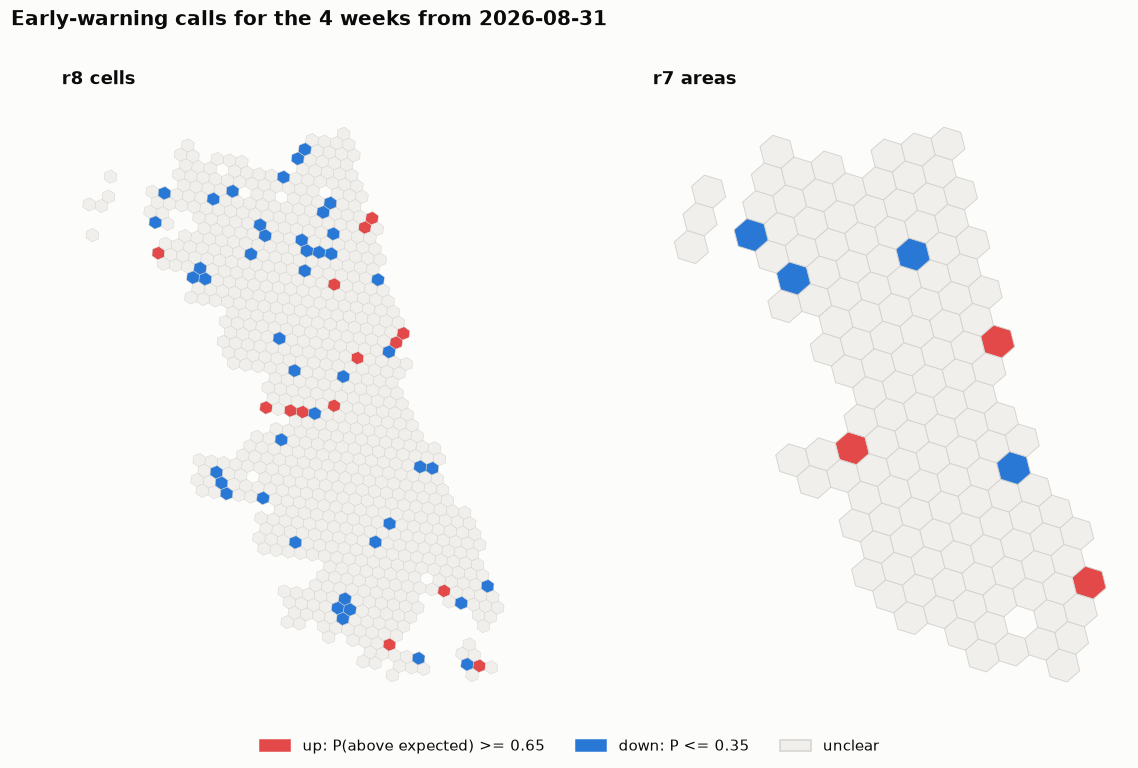

In [15]:
live7 = pl.read_parquet(MODEL / "live_forecast_r7.parquet")
live8 = pl.read_parquet(MODEL / "live_forecast_r8.parquet")
as_of = live7["cutoff"][0]
color_of = {"up": UP, "down": DOWN, "unclear": NEUTRAL}

fig, axes = plt.subplots(1, 2, figsize=(11, 7))
hex_map(axes[0], live8["h3_r8"], [color_of[c] for c in live8["call"]], edge="#d4d3cf", lw=0.3)
axes[0].set_title("r8 cells")
hex_map(axes[1], live7["h3_r7"], [color_of[c] for c in live7["call"]], edge="#d4d3cf", lw=0.6)
axes[1].set_title("r7 areas")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=UP, label="up: P(above expected) >= 0.65"),
                    Patch(color=DOWN, label="down: P <= 0.35"),
                    Patch(facecolor=NEUTRAL, edgecolor="#d4d3cf", label="unclear")],
           loc="lower center", ncols=3)
fig.suptitle(f"Early-warning calls for the 4 weeks from {as_of}", x=0.02, ha="left", fontweight="semibold", fontsize=13)
fig.tight_layout(rect=(0, 0.05, 1, 0.95))

print(live7.group_by("call").len().sort("call"))
live7.filter(pl.col("call") != "unclear").sort("p_above", descending=True).select(
    "h3_id", "community_area", "n_cells", "expected", "forecast", "pct_vs_expected", "p_above", "call")

Most areas are "unclear" in any given month. That's expected, not a flaw, given how much of the
signal is chance. The few up/down calls are the ones worth a closer look.

## 9. What we learned, and what's next

**What the numbers say:**
1. **Most of this problem is noise.** Crime locations are very stable, but the month-to-month
   departures within an area are mostly chance at r8 × 4 weeks.
2. **Crime's own recent history helps a little, and reliably:**
   - momentum, and neighbors' momentum
   - regression to the mean in busy cells
   - reversion after a rise over the year
3. **311 didn't add forecast value here.** It was tested carefully: a placebo, per-type runs, and two
   model families.

**Worth trying next:**
- **Streetlight event study.** Crime near a block while its light is out, vs after it's fixed. This
  tests 311 as a *place-and-moment* signal rather than a cell-month one.
- **Separate targets for violent, property and enforcement-driven crime.** They may behave differently.
- **A 13-week horizon at r7.** It has much less noise (about 28% of variation vs about 66%), at the
  cost of a slower warning.
- **A dedicated citywide model** for the level the baseline sets. It would need a longer history than
  5 years to be trusted.
- **Richer neighborhood context:** population, land use, weather.

**Caveats:**
- Training before 2022 is entirely COVID-era.
- Crime counts reflect reporting and enforcement, not only victimization.
- Late reports are only partly handled. We know the year a case was opened, not the day.